# Install and Load Data

In [ ]:
!pip install ucimlrepo

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. Fetch dataset
parkinsons_telemonitoring = fetch_ucirepo(id=189)
X = parkinsons_telemonitoring.data.features
y = parkinsons_telemonitoring.data.targets

# Combine into one dataframe for easy processing
df = pd.concat([X, y], axis=1)
print(f"Dataset loaded: {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded: 5875 rows and 21 columns.


# Define Severity Levels

/tmp/ipython-input-3638335049.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Severity_Level', data=df, palette='viridis')


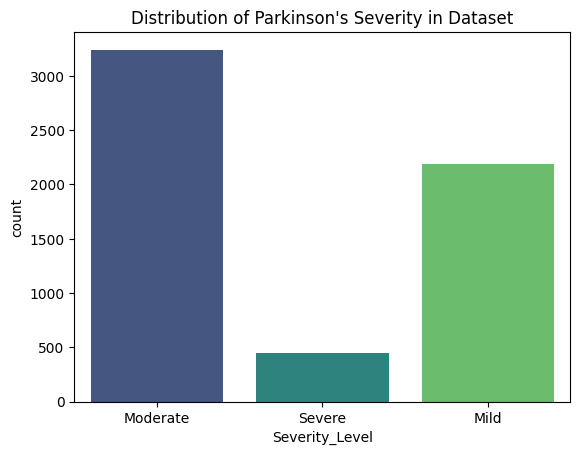

In [ ]:
# Create a 'Severity' column based on total_UPDRS
# Ranges: 0-20 (Mild), 21-40 (Moderate), 41+ (Severe)
def categorize_updrs(score):
    if score <= 25:
        return 'Mild'
    elif score <= 45:
        return 'Moderate'
    else:
        return 'Severe'

df['Severity_Level'] = df['total_UPDRS'].apply(categorize_updrs)

# Visualize the distribution
sns.countplot(x='Severity_Level', data=df, palette='viridis')
plt.title('Distribution of Parkinson\'s Severity in Dataset')
plt.show()

# Preprocessing & Splitting

In [ ]:
# Drop the original scores so the model doesn't "cheat"
# Also drop 'subject#' to ensure we learn speech patterns, not individual people
features = df.drop(['motor_UPDRS', 'total_UPDRS', 'Severity_Level'], axis=1)
target = df['Severity_Level']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

# Scale Features (Critical for voice data!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the Model
Random Forest Classifier

In [ ]:
# Initialize and Train
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Results
print("--- Confusion Matrix ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

--- Confusion Matrix ---
[[376  71   0]
 [ 14 641   0]
 [  2  14  57]]

--- Classification Report ---
              precision    recall  f1-score   support

        Mild       0.96      0.84      0.90       447
    Moderate       0.88      0.98      0.93       655
      Severe       1.00      0.78      0.88        73

    accuracy                           0.91      1175
   macro avg       0.95      0.87      0.90      1175
weighted avg       0.92      0.91      0.91      1175



# Feature Importance (For your Project Report)

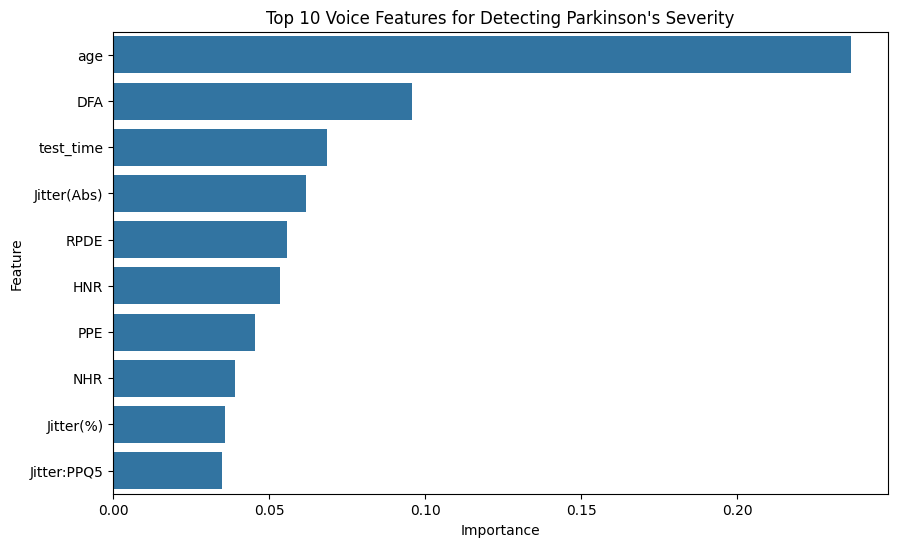

In [ ]:
importances = model.feature_importances_
feature_names = features.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Voice Features for Detecting Parkinson\'s Severity')
plt.show()